# Week 3 — Math for Machine Learning: Linear Algebra, Calculus, Probability, and Statistics

**Course context:** ML models are math with data plugged in. Linear algebra is how data is represented (vectors, matrices) and transformed (matrix multiplication = what every neural network layer does). Calculus (specifically derivatives) is how models *learn* — gradient descent is just "follow the slope downhill." Probability and statistics are how you reason about uncertainty and test whether a result is real or noise.

**You don't need to be a mathematician.** You need to recognize these operations when you see them in ML code (which is constantly) and know what they're doing conceptually. This week builds exactly that.

**How this notebook is organized:** one section per day, each with: what it covers → why it matters for AI work → code → pitfalls.


## Day 1 — Matrices and Vectors: The Basic Operations

**What it covers:** Matrix addition, subtraction, scalar multiplication, matrix-vector multiplication, and special matrices (identity, diagonal, zero).

**Why it matters for AI work:** A dataset is a matrix (rows = examples, columns = features). A neural network layer is: take an input vector, multiply by a weight matrix, add a bias vector. That's it — that operation, repeated across many layers, IS a neural network. Get comfortable with matrix-vector multiplication and a huge chunk of "how neural nets work" stops being mysterious.

**Key matrices to recognize:**
- **Identity matrix** (`np.eye(n)`) — the matrix equivalent of multiplying by 1. `A @ I == A`.
- **Diagonal matrix** (`np.diag([...])`) — zeros everywhere except the diagonal. Used to represent independent scaling per dimension.
- **Zero matrix** — all zeros. Common as an initial state before filling in values.

**Pitfalls:**
- Matrix addition/subtraction requires the **same shape** on both sides. `(2,2) + (3,3)` raises a `ValueError`.
- `np.dot(M, v)` for a matrix-vector product requires the matrix's number of **columns** to match the vector's length. A `(3,3)` matrix needs a length-3 vector.
- Scalar multiplication (`3 * A`) multiplies **every element** — don't confuse this with matrix multiplication, which is a completely different operation.


In [1]:
import numpy as np

A = np.array([[1, 2], [3, 4]])
B = np.array([[9, 8], [7, 6]])

print("Addition:\n", A + B)
print("Subtraction:\n", A - B)
print("Scalar Multiplication (3*A):\n", 3 * A)

Addition:
 [[10 10]
 [10 10]]
Subtraction:
 [[-8 -6]
 [-4 -2]]
Scalar Multiplication (3*A):
 [[ 3  6]
 [ 9 12]]


In [2]:
# Matrix-vector multiplication
M = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
v = np.array([1, 0, -1])

result = np.dot(M, v)   # equivalently: M @ v
print("Matrix-Vector Multiplication:\n", result)

Matrix-Vector Multiplication:
 [-2 -2 -2]


In [3]:
# Special matrices
I = np.eye(3)              # identity matrix
D = np.diag([1, 7, 9])      # diagonal matrix
Z = np.zeros((3, 3))        # zero matrix

A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print("A @ I == A ?\n", np.dot(A, I))   # multiplying by identity leaves A unchanged

print("Diagonal Matrix:\n", D)
print("Zero Matrix:\n", Z)

A @ I == A ?
 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
Diagonal Matrix:
 [[1 0 0]
 [0 7 0]
 [0 0 9]]
Zero Matrix:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## Day 2 — Determinants, Inverses, Eigenvalues, and SVD

**What it covers:** The determinant, matrix inverse, eigenvalues/eigenvectors, and singular value decomposition (SVD).

**Why it matters for AI work:**
- **Inverse** — solving systems of linear equations (the closed-form solution to linear regression uses a matrix inverse).
- **Eigenvalues/eigenvectors** — the math behind PCA (Principal Component Analysis), a standard dimensionality-reduction technique. Eigenvectors point in the directions of maximum variance in your data.
- **SVD** — a more general/stable version of eigendecomposition, used in PCA implementations, recommender systems, and compressing/denoising data.

**When to use what:**
- Determinant — mostly a diagnostic: `det(A) == 0` means the matrix has no inverse (it's "singular") — you're about to hit a wall if your algorithm needs to invert it.
- Eigendecomposition — square matrices only, and works best on well-behaved (symmetric) matrices.
- SVD — works on **any** matrix (even non-square), which is why it's more commonly used in practice than plain eigendecomposition.

**Pitfalls:**
- `np.linalg.inv(A)` on a near-singular matrix (determinant close to 0) gives numerically unstable results — huge, unreliable numbers. This is a common silent source of bugs. Check `np.linalg.det(A)` first if inversion looks unstable.
- Eigenvalues can be **complex numbers**, not just real — this happens for matrices that represent rotations. NumPy will return complex output in that case; don't be surprised by a `(1+2j)`-style number.
- SVD reconstruction (`U @ Sigma @ Vt`) only exactly recovers the original matrix if you keep **all** singular values. Keeping only the top few (as in PCA/compression) gives an *approximation* — that's the point, but know that it's lossy by design.


In [4]:
A = np.array([[2, 3, 4], [4, 5, 6], [7, 8, 9]])

determinant = np.linalg.det(A)
print("Determinant: ", determinant)

if abs(determinant) > 1e-10:   # far from zero -> safe to invert
    inverse = np.linalg.inv(A)
    print("Inverse:\n", inverse)
else:
    print("Matrix is singular (or near-singular) - cannot reliably invert.")

Determinant:  0.0
Matrix is singular (or near-singular) - cannot reliably invert.


In [5]:
# Eigenvalues and eigenvectors
A = np.array([[4, -2], [1, 1]])
eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues: ", eigvals)
print("Eigenvectors:\n", eigvecs)

Eigenvalues:  [3. 2.]
Eigenvectors:
 [[0.89442719 0.70710678]
 [0.4472136  0.70710678]]


In [6]:
# Singular Value Decomposition (SVD)
A = np.array([[3, 1, 1], [-1, 3, 1], [1, 1, 3]])
U, S, Vt = np.linalg.svd(A)

print("U:\n", U)
print("Singular Values:", S)
print("V transpose:\n", Vt)

# Reconstruct the original matrix from its SVD components
Sigma = np.zeros((3, 3))
np.fill_diagonal(Sigma, S)
reconstructed = U @ Sigma @ Vt
print("Reconstructed Matrix (should match A):\n", reconstructed)

U:
 [[-0.57735027  0.57735027 -0.57735027]
 [-0.4412247  -0.81558342 -0.37435872]
 [-0.68701342  0.03860509  0.7256185 ]]
Singular Values: [4.48261292 3.17102979 1.68841687]
V transpose:
 [[-0.4412247  -0.57735027 -0.68701342]
 [ 0.81558342 -0.57735027 -0.03860509]
 [-0.37435872 -0.57735027  0.7256185 ]]
Reconstructed Matrix (should match A):
 [[ 3.  1.  1.]
 [-1.  3.  1.]
 [ 1.  1.  3.]]


## Day 3 — Calculus: Derivatives, Partial Derivatives, and Gradients

**What it covers:** Symbolic differentiation with SymPy, partial derivatives for multivariable functions, and implementing gradient descent from scratch in NumPy.

**Why it matters for AI work:** This is the single most important concept in this week. **Training a model = minimizing a loss function using its gradient.** The gradient tells you which direction increases the loss fastest; you step in the *opposite* direction, repeatedly, until the loss stops decreasing. Every neural network you'll ever train uses exactly this idea (via backpropagation, which is just the chain rule applied automatically).

**When to use what:**
- SymPy (`sp.diff`) — symbolic math, useful for understanding/deriving formulas by hand, or double-checking a gradient formula
- Manual gradient descent in NumPy — how you'd implement optimization for a model that doesn't have a library doing it for you (or to understand what the library IS doing)
- In practice, PyTorch/TensorFlow compute gradients automatically (autodiff) — you'll rarely hand-derive gradients for real models, but you need to understand what's happening when `.backward()` is called

**Pitfalls:**
- Learning rate too high → gradient descent **overshoots** and diverges (loss increases instead of decreases). Too low → painfully slow convergence. This is one of the first hyperparameters you'll tune in Week 8.
- Gradient descent finds a **local** minimum for non-convex functions (most neural network loss surfaces). Linear regression's loss is convex, so this isn't a concern here — it becomes one later with deep networks.
- Forgetting to divide by `m` (number of examples) when averaging gradients — this makes the effective learning rate depend on dataset size, which is a subtle bug.


In [7]:
import sympy as sp

x = sp.Symbol('x')
f = x**3 - 5*x + 7

derivative = sp.diff(f, x)
print("Function: ", f)
print("Derivative: ", derivative)

Function:  x**3 - 5*x + 7
Derivative:  3*x**2 - 5


In [8]:
# Partial derivatives (multivariable calculus)
x, y = sp.symbols('x y')
f = x**2 + 3*y**2 - 4*x*y

grad_x = sp.diff(f, x)
grad_y = sp.diff(f, y)

print("Function: ", f)
print("Gradient w.r.t. x:", grad_x)
print("Gradient w.r.t. y:", grad_y)

Function:  x**2 - 4*x*y + 3*y**2
Gradient w.r.t. x: 2*x - 4*y
Gradient w.r.t. y: -4*x + 6*y


In [9]:
# Gradient descent implemented from scratch (batch gradient descent)
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    for _ in range(iterations):
        predictions = np.dot(X, theta)
        errors = predictions - y
        gradients = (1 / m) * np.dot(X.T, errors)   # average gradient over all examples
        theta -= learning_rate * gradients
    return theta

# Tiny example: fit y = theta0 + theta1 * x1  (X already includes a bias column of 1s)
X = np.array([[1, 1], [1, 2], [1, 3]])
y = np.array([2, 2.5, 3.5])
theta = np.array([0.1, 0.1])

optimized_theta = gradient_descent(X, y, theta, learning_rate=0.1, iterations=1000)
print("Optimized Parameters:", optimized_theta)

Optimized Parameters: [1.166663   0.75000161]


## Day 4 — Integrals and Stochastic Gradient Descent

**What it covers:** Symbolic integration (indefinite and definite), and Stochastic Gradient Descent (SGD) — an alternative to the batch gradient descent from Day 3.

**Why it matters for AI work:** Integration shows up less directly in day-to-day ML code than derivatives, but it underlies probability theory (a probability density function integrates to 1; areas under curves = probabilities). SGD, on the other hand, is what actually trains almost every deep learning model in practice — "SGD" or its variants (Adam, RMSprop) are the optimizer you'll pick in every PyTorch/TensorFlow training script.

**Batch GD vs SGD — when to use which:**
- **Batch GD** (Day 3) — uses the *entire* dataset to compute each gradient step. Accurate, but slow and memory-heavy on large datasets.
- **SGD** — uses **one random example** per step. Much faster per step, noisier path to the minimum, but that noise can actually help escape shallow local minima. In practice, deep learning uses **mini-batch** SGD — a compromise (small batches of e.g. 32-256 examples) — for the best of both worlds.

**Pitfalls:**
- SGD's randomness means results vary run to run unless you seed the random number generator — same reproducibility issue as Week 2 Day 2.
- SGD's loss curve is naturally noisier than batch GD's — a single "bad" step doesn't mean something is wrong, look at the overall trend.
- The number of epochs (full passes through the data) and batch size interact with learning rate — changing one often means you need to retune the others.


In [10]:
x_sym = sp.Symbol('x')
f_sym = sp.exp(-x_sym)

indefinite_integral = sp.integrate(f_sym, x_sym)
print("Indefinite integral of e^-x: ", indefinite_integral)

definite_integral = sp.integrate(f_sym, (x_sym, 0, sp.oo))   # integral from 0 to infinity
print("Definite Integral (0 to infinity): ", definite_integral)

f2 = x_sym**2
print("Definite Integral of x^2 from 0 to 2:", sp.integrate(f2, (x_sym, 0, 2)))

Indefinite integral of e^-x:  -exp(-x)


Definite Integral (0 to infinity):  1
Definite Integral of x^2 from 0 to 2: 8/3


In [11]:
# Stochastic Gradient Descent (SGD) - one random example per update
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)   # true relationship: y = 4 + 3x + noise

X_b = np.c_[np.ones((100, 1)), X]   # add bias column (column of 1s)

def stochastic_gradient_descent(X, y, theta, learning_rate, n_epochs):
    m = len(y)
    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index + 1]
            yi = y[random_index:random_index + 1]
            gradients = 2 * xi.T @ (xi @ theta - yi)
            theta = theta - learning_rate * gradients
    return theta

theta = np.random.randn(2, 1)
theta_opt = stochastic_gradient_descent(X_b, y, theta, learning_rate=0.01, n_epochs=50)
print("Optimized Parameters (true values are ~4 and ~3):\n", theta_opt)

Optimized Parameters (true values are ~4 and ~3):
 [[4.16427183]
 [2.69207144]]


## Day 5 — Probability: Bayes' Theorem and Probability Distributions

**What it covers:** Bayes' theorem (updating a probability given new evidence), and common probability distributions (Gaussian/Normal, Binomial, Poisson).

**Why it matters for AI work:**
- **Bayes' theorem** underlies Naive Bayes classifiers, and more broadly, the whole idea of updating beliefs given data — which is conceptually what training a model IS.
- **Distributions** describe how your data is shaped. The Gaussian (Normal) distribution shows up everywhere (many statistical tests assume it, weight initialization in neural nets often samples from it). Binomial/Poisson model discrete counts (successes out of N trials, event counts per time period) — relevant for things like A/B test analysis or modeling rare events (e.g. fraud detection).

**When to use what:**
- **Gaussian** — continuous data that clusters around a mean (heights, measurement errors, many natural phenomena)
- **Binomial** — number of successes in N independent yes/no trials (e.g. 10 coin flips, how many heads)
- **Poisson** — number of events in a fixed interval, when events are rare and independent (e.g. number of website visits per minute)

**Pitfalls:**
- The classic "medical test" example below is a real gotcha: even with a 95%-accurate test, if the disease is rare (1% prevalence), most positive results are still **false positives**. This is why you always need the prior probability (prevalence), not just the test's accuracy, to interpret a result correctly. Skipping this is a common real-world reasoning error, not just a textbook exercise.
- Don't assume your data is Gaussian without checking (a histogram, Day 2 Week 2 style, is the fast way to check). Many real-world features (income, word frequency) are heavily skewed, not bell-shaped.


In [12]:
# Bayes' theorem: probability of disease given a POSITIVE test result
# - 1% of the population has the disease (prior)
# - Test is 95% accurate for people who DO have it (sensitivity / true positive rate)
# - Test is 90% accurate for people who DON'T have it (specificity / true negative rate)

def bayes_theorem(prior, sensitivity, specificity):
    evidence = (sensitivity * prior) + ((1 - specificity) * (1 - prior))
    posterior = (sensitivity * prior) / evidence
    return posterior

prior = 0.01
sensitivity = 0.95
specificity = 0.90

posterior = bayes_theorem(prior, sensitivity, specificity)
print(f"Probability of actually having the disease given a positive test: {posterior:.2%}")
print("Notice this is much lower than 95% - a rare disease means most positives are false alarms.")

Probability of actually having the disease given a positive test: 8.76%
Notice this is much lower than 95% - a rare disease means most positives are false alarms.


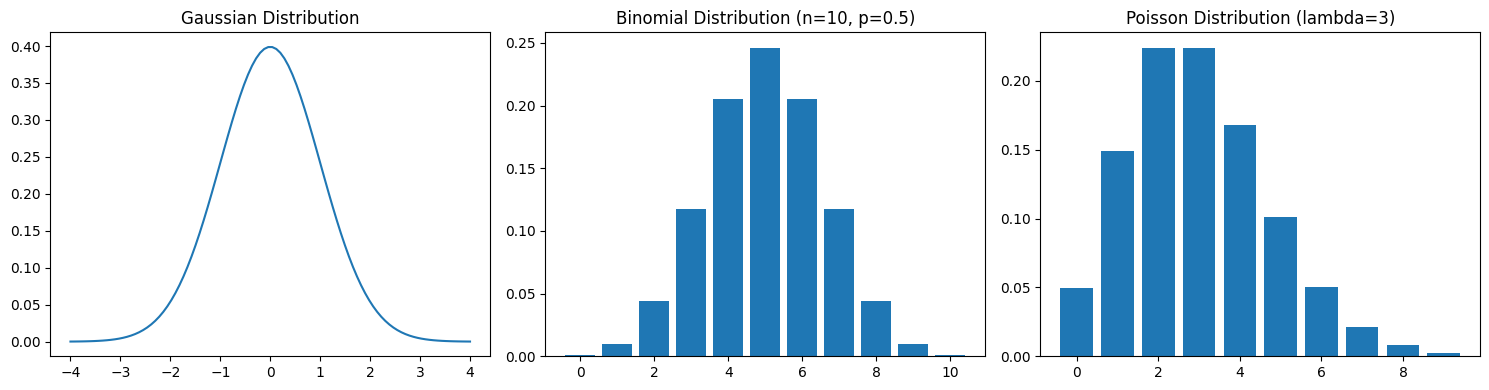

In [13]:
import matplotlib.pyplot as plt
from scipy.stats import norm, binom, poisson

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gaussian (Normal) distribution
x = np.linspace(-4, 4, 100)
axes[0].plot(x, norm.pdf(x, loc=0, scale=1))
axes[0].set_title("Gaussian Distribution")

# Binomial distribution
n, p = 10, 0.5
x_binom = np.arange(0, n + 1)
axes[1].bar(x_binom, binom.pmf(x_binom, n, p))
axes[1].set_title("Binomial Distribution (n=10, p=0.5)")

# Poisson distribution
lam = 3
x_poisson = np.arange(0, 10)
axes[2].bar(x_poisson, poisson.pmf(x_poisson, lam))
axes[2].set_title("Poisson Distribution (lambda=3)")

plt.tight_layout()
plt.show()

## Day 6 — Descriptive Statistics, Confidence Intervals, and Hypothesis Testing

**What it covers:** Mean/variance/standard deviation, confidence intervals, and the t-test for comparing two groups.

**Why it matters for AI work:** Before you can say "Model A is better than Model B," you need statistics to tell you whether the difference is real or just random noise. A/B testing, comparing model versions, and validating whether a data preprocessing change actually helped — all of this is hypothesis testing.

**When to use what:**
- **Confidence interval** — a range that likely contains the true population value, given your sample. Wider interval = less certainty (often from a smaller sample).
- **t-test** (`ttest_ind`) — compare the means of two independent groups (e.g. "does Model A's accuracy differ from Model B's across runs?"). Use ANOVA (`f_oneway`, coming in Week 4) for 3+ groups instead of running multiple t-tests.

**Pitfalls:**
- A p-value below 0.05 does **not** mean "95% probability the effect is real" — it means "if there were truly no effect, you'd see data this extreme only 5% of the time." Subtle distinction, commonly misstated even by people who should know better.
- Statistical significance (`p < 0.05`) is not the same as **practical** significance — with enough data, even a tiny, meaningless difference can be "statistically significant." Always look at effect size, not just the p-value.
- `np.var()` computes the *population* variance by default (divides by N). For a *sample* variance (divides by N-1, used for inferential statistics), pass `ddof=1`.


In [14]:
# Manual mean/variance/std, plus a 95% confidence interval
data = [10, 20, 30, 40, 50]
mean = sum(data) / len(data)
variance = sum((x - mean) ** 2 for x in data) / len(data)
std_dev = variance ** 0.5

z_score = 1.96   # for a 95% confidence interval, assuming a normal distribution
ci = (mean - z_score * (std_dev / len(data) ** 0.5),
      mean + z_score * (std_dev / len(data) ** 0.5))

print("Mean:", mean)
print("Standard Deviation:", std_dev)
print("95% Confidence Interval:", ci)

# Same stats using NumPy directly (sanity check against the manual version above)
print("\nnp.mean:", np.mean(data))
print("np.var (population, ddof=0):", np.var(data))
print("np.std:", np.std(data))

Mean: 30.0
Standard Deviation: 14.142135623730951
95% Confidence Interval: (17.603871572139955, 42.39612842786005)

np.mean: 30.0
np.var (population, ddof=0): 200.0
np.std: 14.142135623730951


In [15]:
# Independent-samples t-test: are these two groups meaningfully different?
from scipy.stats import ttest_ind

group1 = [2.1, 2.5, 2.8, 3.0, 3.2]
group2 = [1.8, 2.0, 2.4, 2.7, 2.9]

t_stat, p_value = ttest_ind(group1, group2)
print("T-Statistic: ", t_stat)
print("P-Value: ", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: statistically significant difference between groups")
else:
    print("Fail to reject the null hypothesis: no statistically significant difference detected")

T-Statistic:  1.272792206135785
P-Value:  0.2388331436303526
Fail to reject the null hypothesis: no statistically significant difference detected


## Day 7 — Mini Project: Linear Regression From Scratch

**What it covers:** Bringing the whole week together — implementing linear regression's prediction formula, training it with gradient descent, and evaluating it with MSE and R² — using only NumPy (no scikit-learn).

**Why it matters for AI work:** This is the "hello world" of ML, and doing it from scratch once is genuinely worth it — Week 5 onward you'll use `sklearn.linear_model.LinearRegression()` in one line, but knowing what that line does internally (this exact math) is the difference between using ML as a black box and actually understanding it.

**What each evaluation metric tells you:**
- **MSE (Mean Squared Error)** — average squared difference between predictions and actual values. Lower is better. Squaring penalizes large errors more than small ones, and means the units are "squared" (e.g. dollars², not dollars) — often easier to interpret via RMSE (its square root).
- **R² (R-squared)** — proportion of variance in the target explained by the model, from 0 to 1 (can go negative for a very bad model). `R² = 0.8` means the model explains 80% of the variation in the data. Higher is better, but a high R² on training data alone doesn't guarantee the model generalizes — that's what Week 5's train/test split is for.

**Pitfalls:**
- This mini-project trains and evaluates on the **same** data — there's no train/test split yet. That means this R²/MSE tells you how well the model fits data it already saw, not how well it'll perform on new data. Week 5 introduces the train/test split that fixes this.
- MSE is sensitive to outliers (because of the squaring) — one badly wrong prediction can dominate the metric.


In [16]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)   # true relationship: y = 4 + 3x + noise

X_b = np.c_[np.ones((100, 1)), X]   # bias column

theta = np.random.randn(2, 1)
learning_rate = 0.1
iterations = 1000

def predict(X, theta):
    return np.dot(X, theta)

def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    for _ in range(iterations):
        gradients = (1 / m) * np.dot(X.T, (np.dot(X, theta) - y))
        theta = theta - learning_rate * gradients
    return theta

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

theta_optimized = gradient_descent(X_b, y, theta, learning_rate, iterations)
y_pred = predict(X_b, theta_optimized)

mse = mean_squared_error(y, y_pred)
r2 = r_squared(y, y_pred)

print("Optimized Parameters (theta) - true values are ~4 and ~3:\n", theta_optimized)
print("MSE:", mse)
print("R2:", r2)

Optimized Parameters (theta) - true values are ~4 and ~3:
 [[4.21509609]
 [2.77011344]]
MSE: 0.8065845639670546
R2: 0.769273541361422


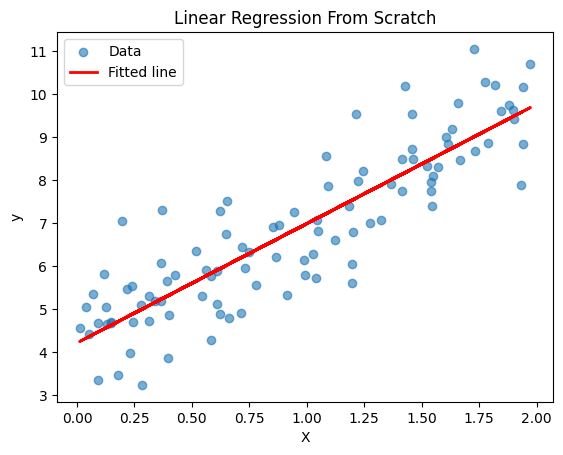

In [17]:
import matplotlib.pyplot as plt

plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, predict(X_b, theta_optimized), color="red", linewidth=2, label="Fitted line")
plt.title("Linear Regression From Scratch")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Week 3 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | Matrix/vector operations | Every neural network layer |
| 2 | Determinants, eigenvalues, SVD | PCA, dimensionality reduction |
| 3 | Derivatives, gradients | Understanding how models learn (all of ML/DL) |
| 4 | Integrals, SGD | The actual optimizer used to train deep networks |
| 5 | Bayes, distributions | Naive Bayes, understanding data shape |
| 6 | Confidence intervals, t-tests | Comparing models/experiments rigorously |
| 7 | Linear regression from scratch | The math behind `sklearn.LinearRegression()` |

**Before moving to Week 4:** you should be able to explain, in plain words, what a gradient is and why gradient descent works, without needing the formula in front of you. That intuition is the single most reused idea in the rest of this course.
